In [4]:
import os

# Tránh lỗi crash do xung đột OpenMP/MKL ở một số môi trường
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torchvision
import torchvision.transforms as transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)


torch: 2.4.0+cpu
torchvision: 0.19.0+cpu


In [ ]:
# Cấu hình chung: đảm bảo folder `Data/` nằm cùng cấp với `src/`
from pathlib import Path

cwd = Path.cwd().resolve()
if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif cwd.name == "src":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_ROOT = PROJECT_ROOT / "Data"  

print("CWD        :", cwd)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT  :", DATA_ROOT)


CWD        : /home/hoang/Image-Retrieval-System/src
PROJECT_ROOT: /home/hoang/Image-Retrieval-System
DATA_ROOT  : /home/hoang/Image-Retrieval-System/Data


In [ ]:
# 1) Download CIFAR-10 (train + test)
# Lần đầu chạy sẽ download về DATA_ROOT
_ = torchvision.datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=False)
_ = torchvision.datasets.CIFAR10(root=str(DATA_ROOT), train=False, download=False)

print("Đảm bảo CIFAR-10 tồn tại trong:", DATA_ROOT)


100.0%


Extracting /home/hoang/Image-Retrieval-System/Data/cifar-10-python.tar.gz to /home/hoang/Image-Retrieval-System/Data
Files already downloaded and verified
Đã đảm bảo CIFAR-10 tồn tại trong: /home/hoang/Image-Retrieval-System/Data


In [ ]:
# 2) Pipeline tiền xử lý giống ImageNet (phù hợp ResNet-18 pretrained)
from typing import Any


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

trainset = torchvision.datasets.CIFAR10(root=str(DATA_ROOT), train=True, download=False, transform=transform)
testset  = torchvision.datasets.CIFAR10(root=str(DATA_ROOT), train=False, download=False, transform=transform)

print("Số ảnh train:", len(trainset))
print("Số ảnh test :", len(testset))
print("Tổng        :", len(trainset) + len(testset))
x, y = trainset[0]
print("1 sample shape:", tuple[Any, ...](x.shape), "label:", y)


Số ảnh train: 50000
Số ảnh test : 10000
Tổng        : 60000
1 sample shape: (3, 224, 224) label: 6


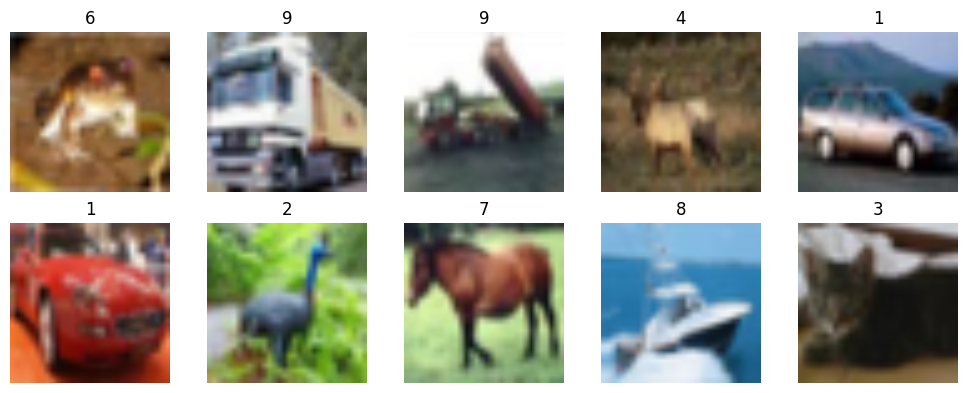

In [13]:
# 3) Hiển thị nhanh vài ảnh (denormalize để ra màu đúng)
import matplotlib.pyplot as plt

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize(t: torch.Tensor) -> torch.Tensor:
    t = t.clone()
    t = t * std + mean
    return torch.clamp(t, 0, 1)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img_tensor, label = trainset[i]
    img_show = denormalize(img_tensor).permute(1, 2, 0)
    ax.imshow(img_show)
    ax.set_title(str(label))
    ax.axis("off")
plt.tight_layout()
plt.show()
